# File and Data Field Descriptions

- **train.csv** - Personal records for about two-thirds (~8700) of the passengers, to be used as training data.
  - **PassengerId** - A unique Id for each passenger. Each Id takes the form gggg\*pp where \*\*\_gggg indicates a group the passenger is travelling**\* with and **_pp is their number within the group_\*\*. People in a group are often family members, but not always.
  - **HomePlanet** - The planet the passenger departed from, typically their planet of permanent residence.
  - **CryoSleep** - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
  - **Cabin** - The cabin number where the passenger is staying. Takes the form **_deck/num/side, where side can be either P for Port or S for Starboard_**.
  - **Destination** - The planet the passenger will be debarking to.
  - **Age** - The age of the passenger.
  - **VIP** - Whether the passenger has **_paid for special VIP service_** during the voyage.
  - **RoomService, FoodCourt, ShoppingMall, Spa, VRDeck** - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
  - **Name** - The first and last names of the passenger.
  - **Transported** - Whether the passenger was transported to another dimension. **This is the target**, the column you are trying to predict.
- **test.csv** - Personal records for the remaining one-third (~4300) of the passengers, to be used as test data. Your task is to predict the value of Transported for the passengers in this set.
- **sample_submission.csv** - A submission file in the correct format.
  - **PassengerId** - Id for each passenger in the test set.
  - **Transported** - The target. For each passenger, predict either True or False.


### Import and Setup


In [87]:
# data analysis and wrangling
import pandas as pd
import numpy as np
import random as rnd
import pickle

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# machine learning
from scipy.stats import chi2_contingency
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron, SGDClassifier, LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score


SEED = 42
np.random.seed(SEED)

In [88]:
df_train = pd.read_csv("../data/spaceship-titanic/train.csv")
df_test = pd.read_csv("../data/spaceship-titanic/test.csv")

# labels = df_train["Transported"]
# y_test = df_test["Transported"]

# df_train.drop(["Transported"], axis=1, inplace=True)
# df_test.drop(["Transported"], axis=1, inplace=True)

In [89]:
combined = pd.concat([df_train, df_test], sort=False).reset_index(drop=True)
combined.isnull().sum()

PassengerId        0
HomePlanet       288
CryoSleep        310
Cabin            299
Destination      274
Age              270
VIP              296
RoomService      263
FoodCourt        289
ShoppingMall     306
Spa              284
VRDeck           268
Name             294
Transported     4277
dtype: int64

### EDA


In [7]:
combined["HomePlanet"].value_counts()

HomePlanet
Earth     6865
Europa    3133
Mars      2684
Name: count, dtype: int64

In [8]:
# Jeder Passanger ist einzigartig.
combined.select_dtypes(include=["O"]).nunique()

PassengerId    12970
HomePlanet         3
CryoSleep          2
Cabin           9825
Destination        3
VIP                2
Name           12629
Transported        2
dtype: int64

In [9]:
combined.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,12700.000000,12707.000000,12681.000000,12664.000000,12686.000000,12702.000000
mean,28.771969,222.897852,451.961675,174.906033,308.476904,306.789482
std,14.387261,647.596664,1584.370747,590.558690,1130.279641,1180.097223
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,49.000000,77.000000,29.000000,57.000000,42.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [10]:
combined["Duration"] = combined.groupby(["Destination", "HomePlanet"])["CryoSleep"].transform("count")

In [11]:
combined[["CryoSleep", "Duration", "Destination", "HomePlanet"]].sort_values(
    by=["CryoSleep", "Duration"], ascending=[False, True]
)

,CryoSleep,Duration,Destination,HomePlanet
1217,True,29.0,PSO J318.5-22,Europa
2218,True,29.0,PSO J318.5-22,Europa
2520,True,29.0,PSO J318.5-22,Europa
6780,True,29.0,PSO J318.5-22,Europa
6966,True,29.0,PSO J318.5-22,Europa
...,...,...,...,...
10252,NaN,NaN,NaN,Europa
10741,NaN,NaN,TRAPPIST-1e,NaN
10984,NaN,NaN,PSO J318.5-22,NaN
11612,NaN,NaN,NaN,Earth


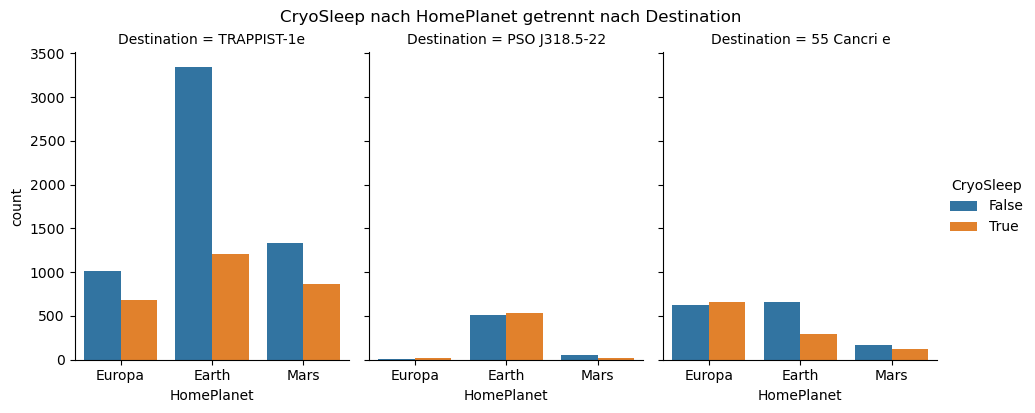

In [12]:
sns.catplot(
    data=combined.dropna(subset=["HomePlanet", "Destination", "CryoSleep"]),
    x="HomePlanet",
    hue="CryoSleep",
    col="Destination",
    kind="count",
    height=4,
    aspect=0.8,
)
plt.suptitle("CryoSleep nach HomePlanet getrennt nach Destination", y=1.02)
plt.show()

In [13]:
def plt_dist_for_col(df, col, hue, bin=None):

    if bin is not None:
        col_binned = pd.qcut(df[col], bin, duplicates="drop")

    else:
        col_binned = df[col]

    pivot = pd.crosstab(col_binned, df[hue])
    percentages = pivot.div(pivot.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(12, 6))
    percentages.plot(kind="bar", stacked=True, ax=ax, color=["#0d9f14", "#dc0d0d"])
    plt.xlabel(col, size=15)
    plt.ylabel("Percentage", size=15)
    plt.title("{} Percentage in {}".format(hue, col), size=18)
    plt.legend(["Not {}".format(hue), hue], loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [14]:
combined["Deck"] = combined["Cabin"].apply(lambda x: str(x).split("/")[0] if pd.notnull(x) else "M")  # M = Missing
combined["Side"] = combined["Cabin"].apply(lambda x: str(x).split("/")[2] if pd.notnull(x) else "M")

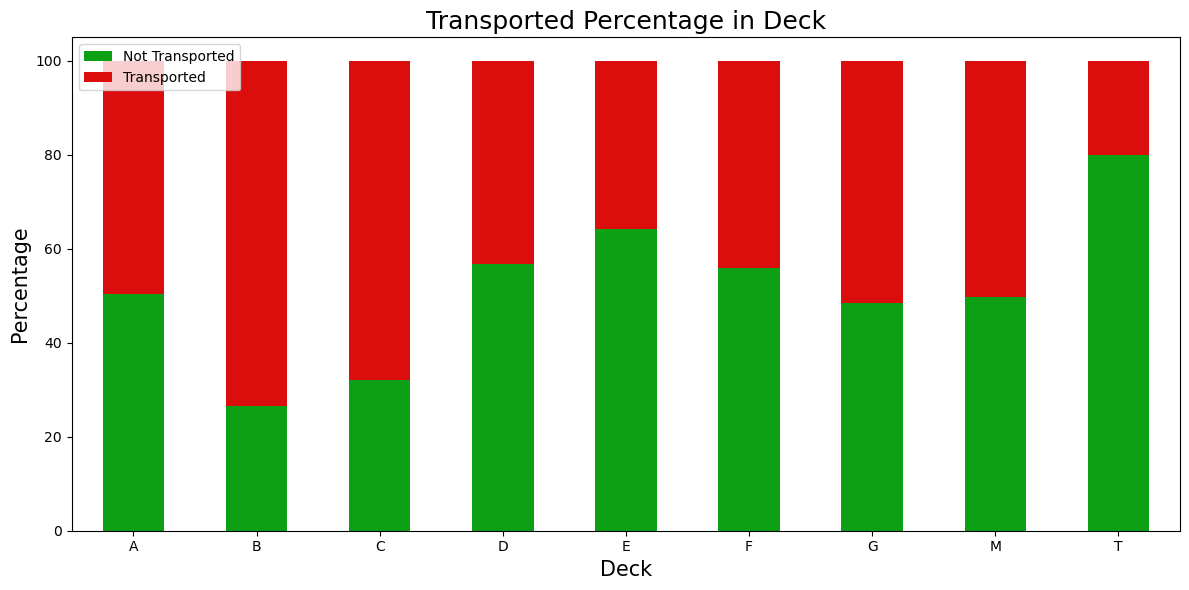

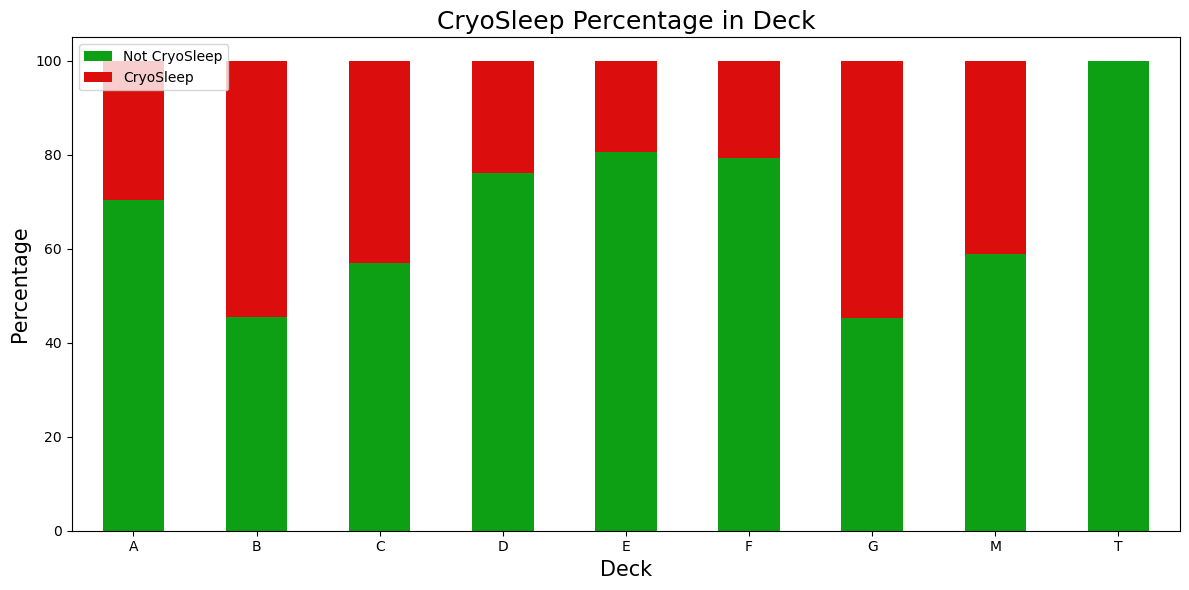

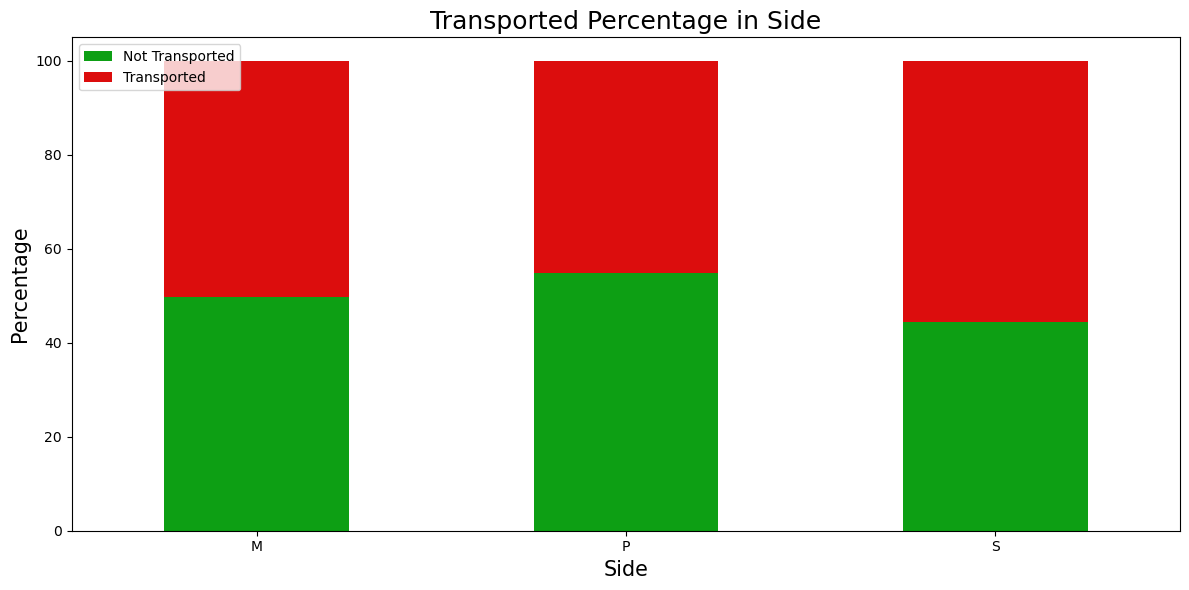

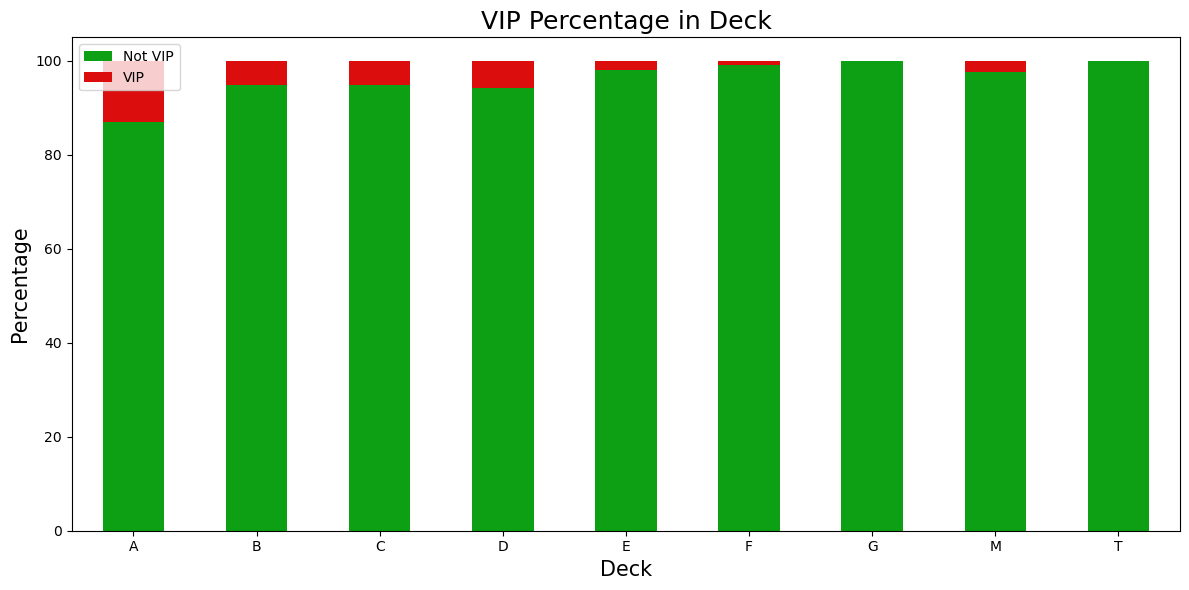

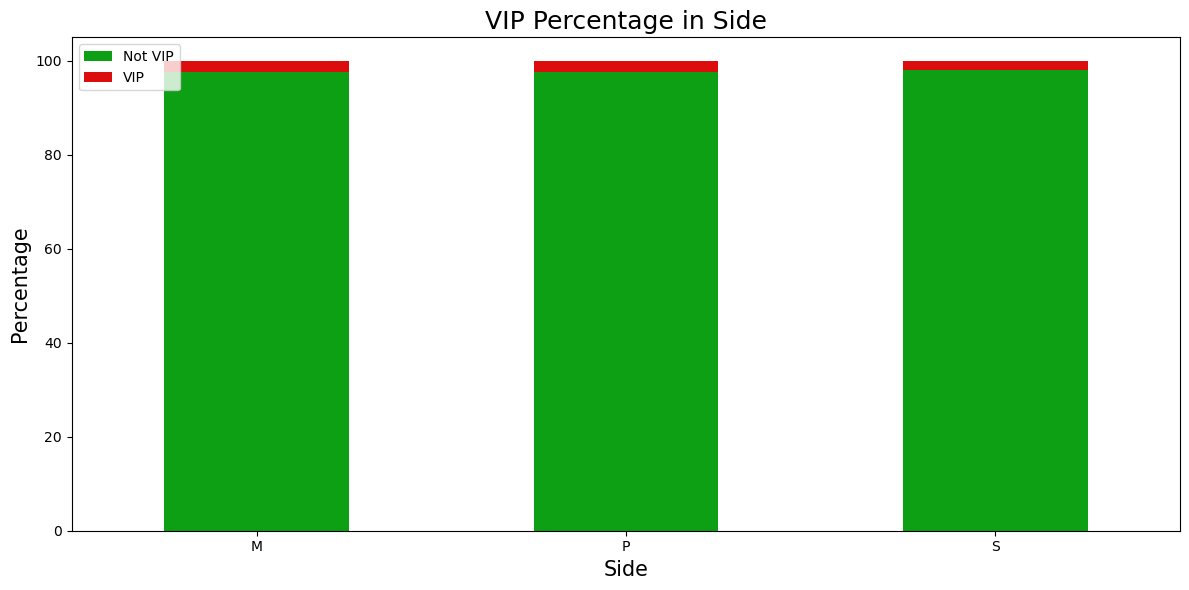

In [15]:
test = combined.copy()
test["Deck"] = test["Cabin"].apply(lambda x: str(x).split("/")[0] if pd.notnull(x) else "M")  # M = Missing
test["Side"] = test["Cabin"].apply(lambda x: str(x).split("/")[2] if pd.notnull(x) else "M")


plt_dist_for_col(test, "Deck", "Transported")
plt_dist_for_col(test, "Deck", "CryoSleep")
plt_dist_for_col(test, "Side", "Transported")
plt_dist_for_col(test, "Deck", "VIP")
plt_dist_for_col(test, "Side", "VIP")

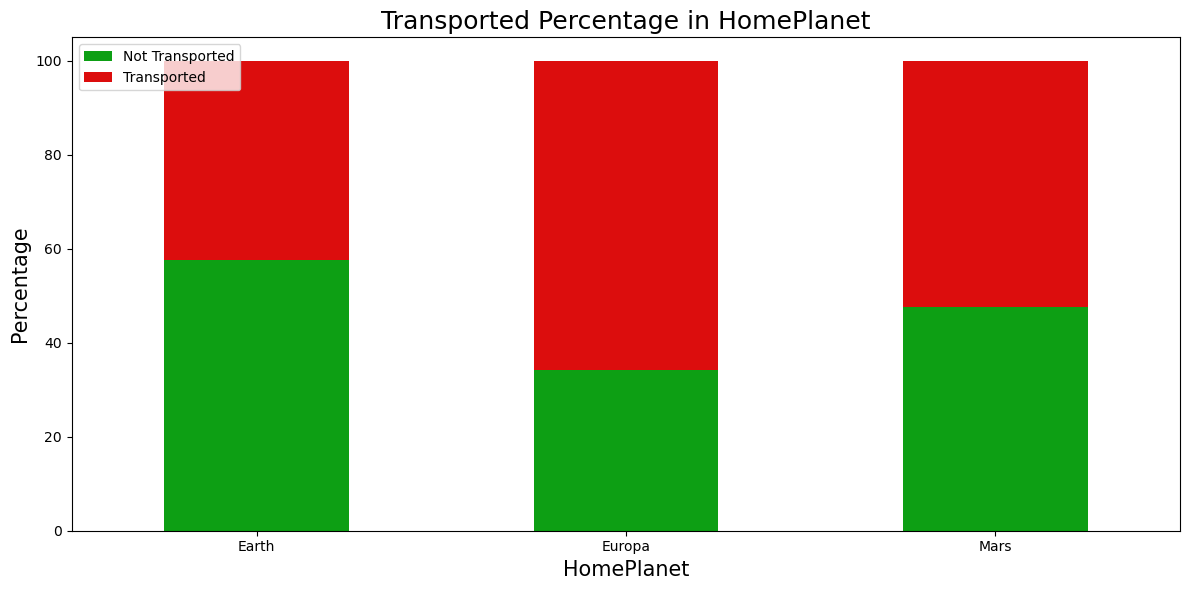

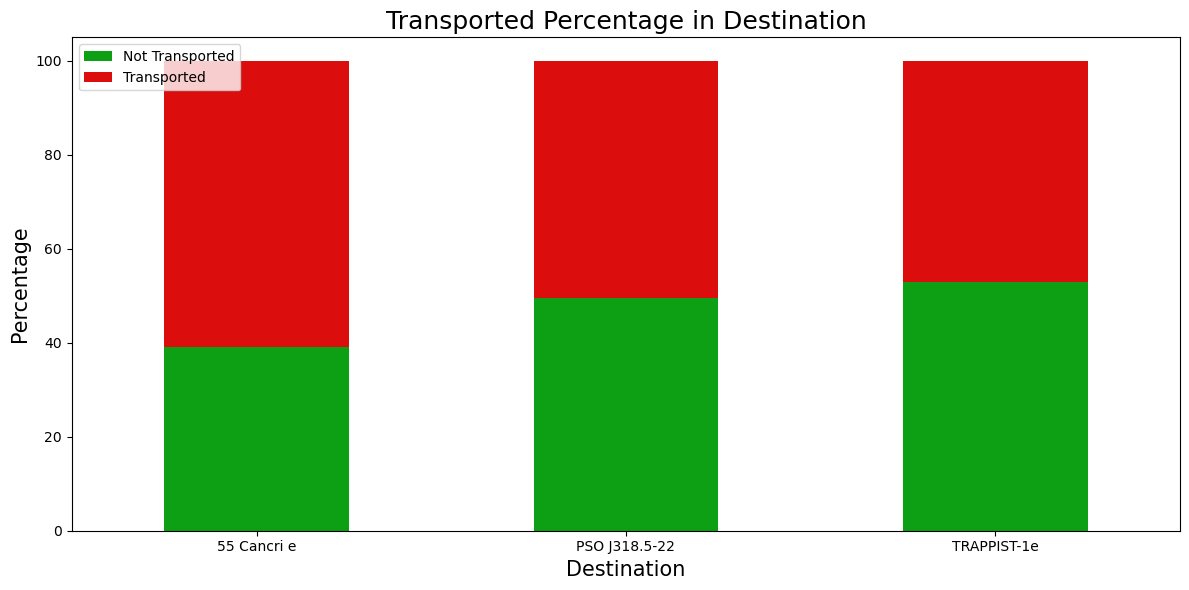

In [16]:
plt_dist_for_col(combined, "HomePlanet", "Transported")
plt_dist_for_col(combined, "Destination", "Transported")

In [18]:
# plt_dist_for_col(combined, "FamilySize", "Transported")
# plt_dist_for_col(combined, "Age", "Transported", 5)

In [19]:
test = combined.copy()

In [20]:
# Old code - No difference between both Variants
test["FoodCourt"] = test["FoodCourt"].fillna(0)
test["ShoppingMall"] = test["ShoppingMall"].fillna(0)
test["Spa"] = test["Spa"].fillna(0)
test["VRDeck"] = test["VRDeck"].fillna(0)
test["RoomService"] = test["RoomService"].fillna(0)

test["BalanceSimple"] = test["RoomService"] + test["FoodCourt"] + test["ShoppingMall"] + test["Spa"] + test["VRDeck"]

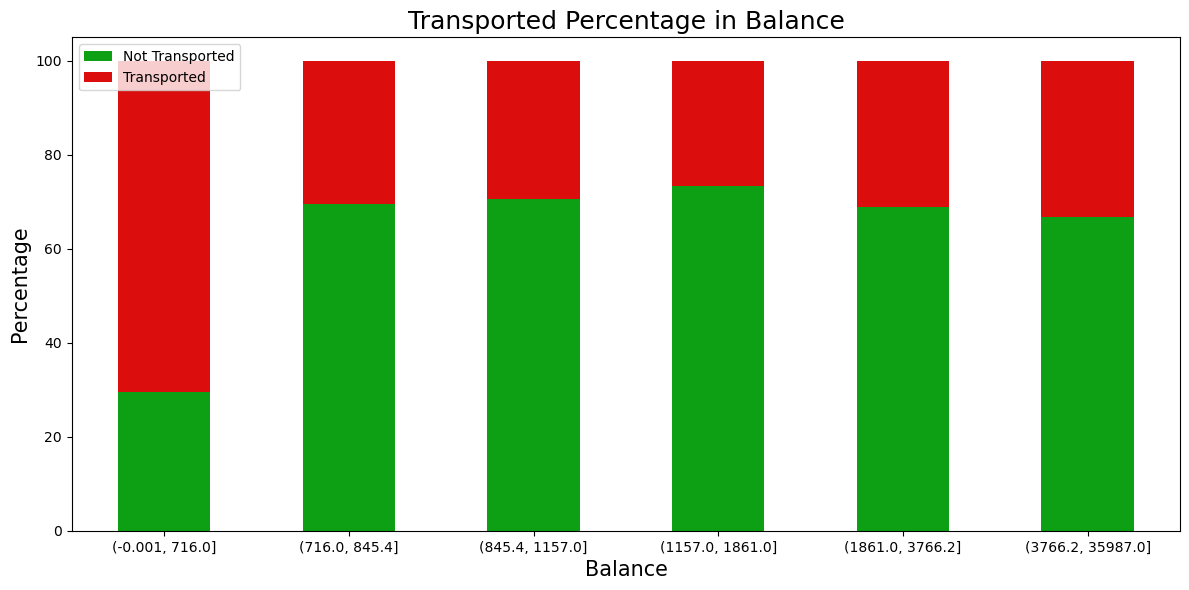

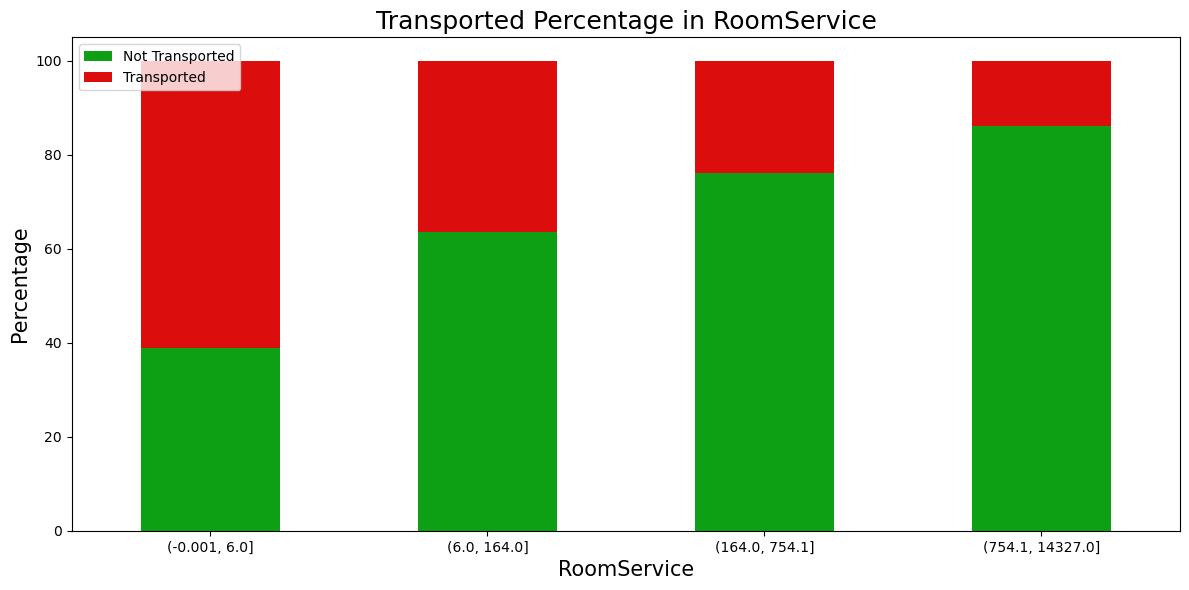

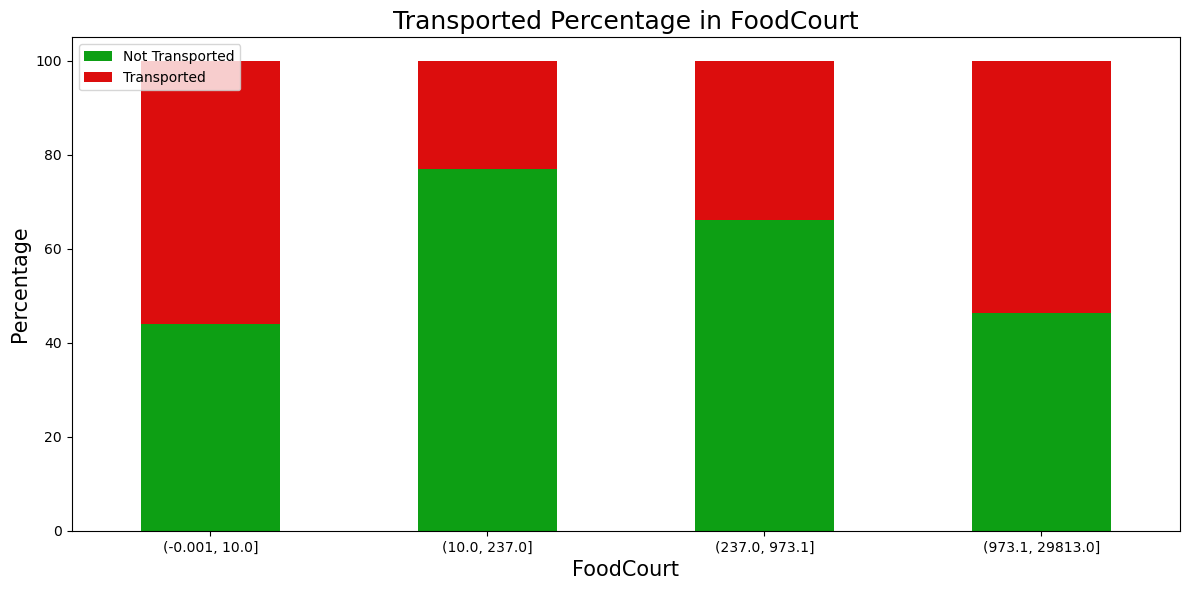

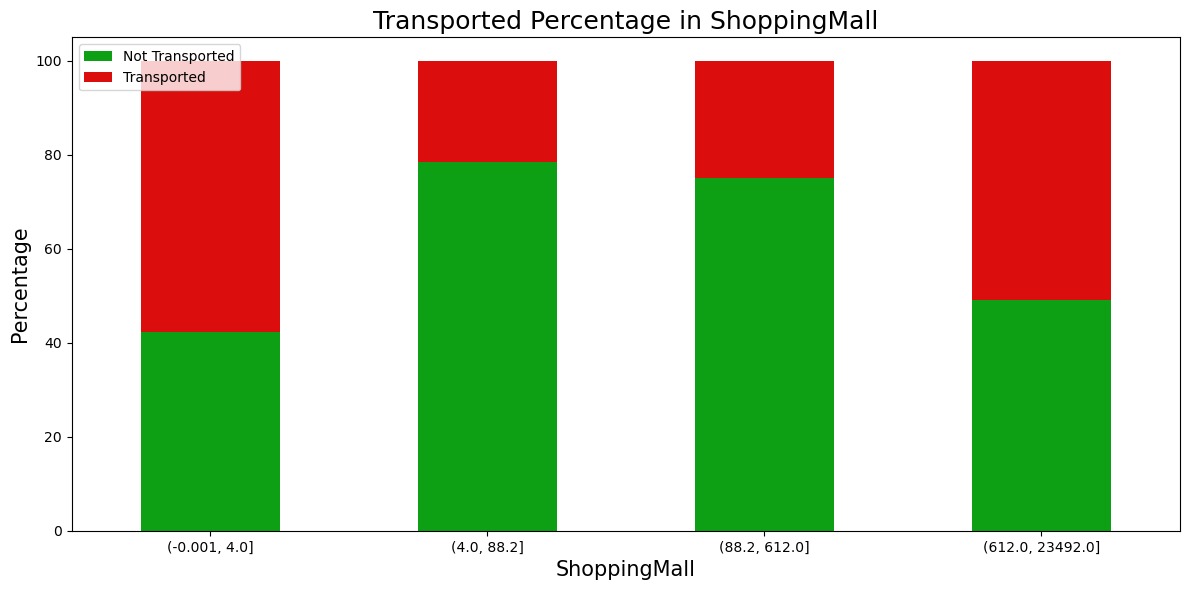

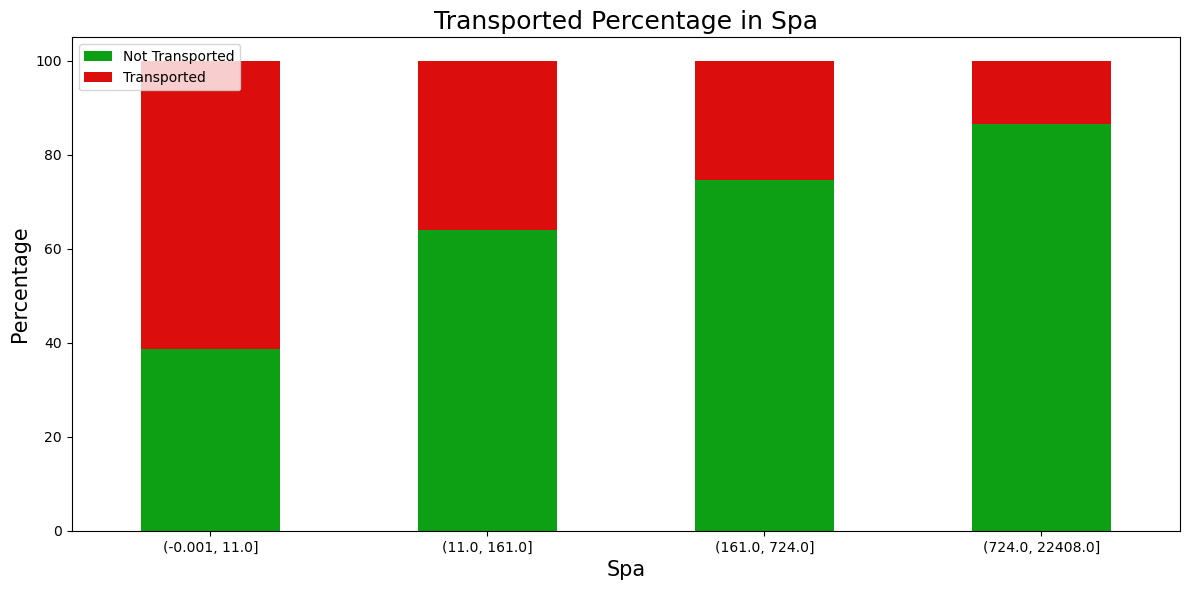

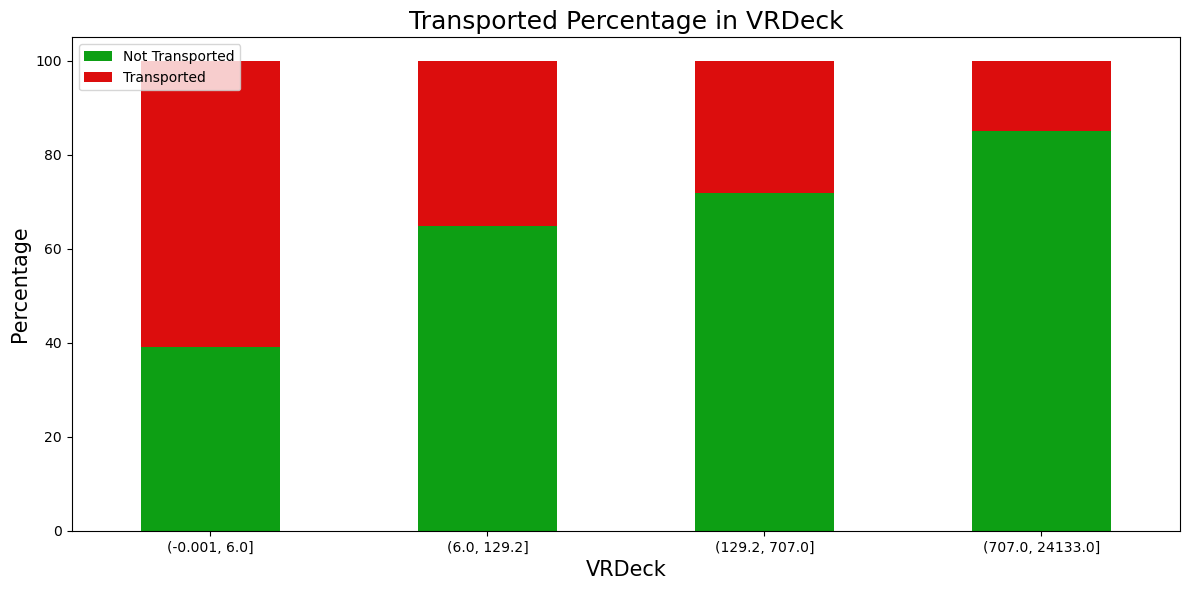

In [21]:
# Fill missing values with median and adds the sum as Balance

cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
test[cols] = test[cols].fillna(test[cols].median())
test["Balance"] = test[cols].sum(axis=1)

plt_dist_for_col(test, "Balance", "Transported", 10)
for col in cols:
    plt_dist_for_col(test, col, "Transported", 10)

### Looking for ways to fill missing values


In [22]:
pd.concat(g for _, g in combined.groupby("Name") if len(g) > 1)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Duration,Deck,Side
2404,2589_01,Europa,True,C/91/P,TRAPPIST-1e,26.0,False,0.0,0.0,0.0,0.0,0.0,Alasmon Meteet,True,1691.0,C,P
9286,1219_02,Europa,True,B/52/S,55 Cancri e,23.0,False,0.0,0.0,0.0,0.0,0.0,Alasmon Meteet,NaN,1278.0,B,S
6296,6665_01,Europa,True,B/222/P,55 Cancri e,17.0,False,0.0,0.0,0.0,0.0,0.0,Alraium Disivering,True,1278.0,B,P
7270,7775_01,Europa,False,C/253/P,55 Cancri e,28.0,False,7.0,489.0,0.0,4.0,6027.0,Alraium Disivering,False,1278.0,C,P
476,0512_02,Europa,True,D/18/S,TRAPPIST-1e,55.0,False,0.0,0.0,0.0,0.0,0.0,Ankalik Nateansive,True,1691.0,D,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3381,3640_02,Earth,True,G/589/S,TRAPPIST-1e,41.0,False,0.0,0.0,0.0,0.0,0.0,Troya Schwardson,False,4557.0,G,S
895,0964_02,Europa,True,B/36/P,TRAPPIST-1e,48.0,False,0.0,0.0,0.0,0.0,0.0,Weidus Platch,True,1691.0,B,P
10002,2808_01,Europa,True,C/95/P,55 Cancri e,30.0,False,0.0,0.0,0.0,0.0,0.0,Weidus Platch,NaN,1278.0,C,P
6231,6591_01,Earth,False,F/1261/S,TRAPPIST-1e,47.0,False,285.0,600.0,3.0,0.0,640.0,Willy Mcfarleys,False,4557.0,F,S


In [23]:
# cabins = combined.copy()
combined["Deck"] = combined["Cabin"].apply(lambda x: str(x).split("/")[0] if pd.notnull(x) else "M")

# cabins["FamilySize"] = cabins.groupby("Cabin")["Cabin"].transform("count")

In [24]:
combined[["CryoSleep", "Transported"]].groupby(["CryoSleep"], as_index=False).mean().sort_values(
    by="Transported", ascending=False
)

,CryoSleep,Transported
1,True,0.817583
0,False,0.328921


In [26]:
# combined["Balance"] = combined[num_cols].sum(axis=1)

df_all_corr = (
    combined.select_dtypes(include=[np.number])
    .corr()
    .abs()
    .unstack()
    .sort_values(kind="quicksort", ascending=False)
    .reset_index()
)
df_all_corr.rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: "Correlation Coefficient"}, inplace=True)
df_all_corr[df_all_corr["Feature 1"] == "Age"]

,Feature 1,Feature 2,Correlation Coefficient
0,Age,Age,1.000000
15,Age,FoodCourt,0.124447
18,Age,Spa,0.118992
22,Age,Duration,0.104964
25,Age,VRDeck,0.101441
28,Age,RoomService,0.067300
34,Age,ShoppingMall,0.034959


### Advance Feature Engineering


Komplexes Featureengineering:

- <del> FamilySize = (LastName _ GroupId) + (GroupId _ Cabin) </del>
  - <del> Drop: LastName, GroupId </del>
  - Bin: Small, Medium, Large -> Ordinal
- <del> Cabin: Deck und Side -> Deck = Erster String, Side = Dritter String </del>
  - <del> Drop: Cabin, Side (geringer Mehrwert) </del>
- <del> Balance = (RoomService + FoodCourt + ShoppingMall + Spa + VRDeck) </del>
  - <del> Drop: Alle behalten </del>
  - Bin: qcut -> small, medium, large, whale
  - Fill: SimpeleImputer mit median
- <del> CryoSleep, VIP: zum Integer umwandeln </del>
  - <del> Fill: SimpeleImputer mit median </del>
- Duration:
- <del> Drop: PassengerId, Transported, LastName, Name </del>

Fill Values:

- <del> CryoSleep wichtig, da hohe cor. </del>
- <del> Homeplanet -> mit Deck vorhersagen </del>
- Num-Fill mit SimpleImputer:
- Cat-Fill mit SimpleImputer:
  - Destination, VIP,

Modelltraining:

- Ensemble mit drei Modellen
- CrossVal für bessere Validierung


In [46]:
combined = pd.concat([df_train, df_test], sort=False).reset_index(drop=True)

In [47]:
combined["Deck"] = combined["Cabin"].apply(lambda x: str(x).split("/")[0] if pd.notnull(x) else "M")  # M = Missing
combined["Side"] = combined["Cabin"].apply(lambda x: str(x).split("/")[2] if pd.notnull(x) else "M")

In [48]:
fill_hp = combined.groupby(["Deck", "Destination"])["HomePlanet"].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else "Earth"
)
fill_cs = combined.groupby(["Deck"])["CryoSleep"].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else "False"
)

combined["HomePlanet"].fillna(fill_hp, inplace=True)
combined["CryoSleep"].fillna(fill_cs, inplace=True)

In [49]:
cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
combined[cols] = combined[cols].fillna(combined[cols].median())
combined["Balance"] = combined[cols].sum(axis=1)

In [50]:
num_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

nummeric_imputation = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(combined[num_cols]),
    columns=combined[num_cols].columns,
)
nummeric_imputation

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,0.0,0.0,0.0,0.0,0.0
1,109.0,9.0,25.0,549.0,44.0
2,43.0,3576.0,0.0,6715.0,49.0
3,0.0,1283.0,371.0,3329.0,193.0
4,303.0,70.0,151.0,565.0,2.0
...,...,...,...,...,...
12965,0.0,0.0,0.0,0.0,0.0
12966,0.0,847.0,17.0,10.0,144.0
12967,0.0,0.0,0.0,0.0,0.0
12968,0.0,2680.0,0.0,0.0,523.0


In [51]:
cat_cols = ["HomePlanet", "Destination", "VIP", "Cabin", "Name"]
cat_imputation = pd.DataFrame(
    SimpleImputer(strategy="most_frequent").fit_transform(combined[cat_cols]),
    columns=combined[cat_cols].columns,
)
cat_imputation

,HomePlanet,Destination,VIP,Cabin,Name
0,Europa,TRAPPIST-1e,False,B/0/P,Maham Ofracculy
1,Earth,TRAPPIST-1e,False,F/0/S,Juanna Vines
2,Europa,TRAPPIST-1e,True,A/0/S,Altark Susent
3,Europa,TRAPPIST-1e,False,A/0/S,Solam Susent
4,Earth,TRAPPIST-1e,False,F/1/S,Willy Santantines
...,...,...,...,...,...
12965,Earth,TRAPPIST-1e,False,G/1496/S,Jeron Peter
12966,Earth,TRAPPIST-1e,False,G/160/P,Matty Scheron
12967,Mars,55 Cancri e,False,D/296/P,Jayrin Pore
12968,Europa,TRAPPIST-1e,False,D/297/P,Kitakan Conale


In [52]:
combined[num_cols] = nummeric_imputation
combined[cat_cols] = cat_imputation

In [53]:
combined["LastName"] = combined["Name"].apply(lambda x: str(x).split(" ")[-1] if pd.notnull(x) else x)
combined["GroupId"] = combined["PassengerId"].apply(lambda x: str(x).split("_")[0] if pd.notnull(x) else x)

count_name = combined.groupby(["GroupId", "LastName"])["PassengerId"].transform("count")
count_cabin = combined.groupby(["GroupId", "Cabin"])["PassengerId"].transform("count")

combined["FamilySize"] = np.maximum(count_name.fillna(0), count_cabin.fillna(0))

combined["IsAlone"] = (combined["FamilySize"] == 1).astype(int)

combined[combined["FamilySize"] > 1].sort_values(["GroupId", "FamilySize"], ascending=[False, True])

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,VRDeck,Name,Transported,Deck,Side,Balance,LastName,GroupId,FamilySize,IsAlone
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,...,3235.0,Celeon Hontichre,False,E,S,4637.0,Hontichre,9280,2,0
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,...,12.0,Propsh Hontichre,True,E,S,4826.0,Hontichre,9280,2,0
8685,9275_01,Europa,False,A/97/P,TRAPPIST-1e,0.0,False,0.0,0.0,0.0,...,0.0,Polaton Conable,True,A,P,0.0,Conable,9275,3,0
8686,9275_02,Europa,False,A/97/P,TRAPPIST-1e,32.0,False,1.0,1146.0,0.0,...,34.0,Diram Conable,False,A,P,1231.0,Conable,9275,3,0
8687,9275_03,Europa,False,A/97/P,TRAPPIST-1e,30.0,False,0.0,3208.0,0.0,...,330.0,Atlasym Conable,True,A,P,3540.0,Conable,9275,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,0008_03,Europa,False,B/1/P,55 Cancri e,45.0,False,39.0,7295.0,589.0,...,124.0,Wezena Flatic,True,B,P,8157.0,Flatic,0008,3,0
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,...,0.0,Billex Jacostaffey,True,F,S,1584.0,Jacostaffey,0006,2,0
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,...,0.0,Candra Jacostaffey,True,G,S,0.0,Jacostaffey,0006,2,0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,49.0,Altark Susent,False,A,S,10383.0,Susent,0003,2,0


In [54]:
# Kein Mehrwert fuer "age"

# combined["VIP"].fillna(False, inplace=True)
# combined["VIP"] = combined["VIP"].astype(int)
# combined["CryoSleep"] = combined["CryoSleep"].astype(int)

In [55]:
df_all_corr = (
    combined.select_dtypes(include=[np.number])
    .corr()
    .abs()
    .unstack()
    .sort_values(kind="quicksort", ascending=False)
    .reset_index()
)
df_all_corr.rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: "Correlation Coefficient"}, inplace=True)
df_all_corr[df_all_corr["Feature 1"] == "Age"]

,Feature 1,Feature 2,Correlation Coefficient
0,Age,Age,1.000000
26,Age,Balance,0.179890
28,Age,FamilySize,0.169218
32,Age,IsAlone,0.126578
34,Age,FoodCourt,0.122816
35,Age,Spa,0.117427
37,Age,VRDeck,0.100759
39,Age,RoomService,0.067259
56,Age,ShoppingMall,0.034632


In [56]:
fill_age = combined.groupby(["Balance", "FamilySize"])["Age"].transform("median")
combined["Age"].fillna(fill_age, inplace=True)
combined["Age"].fillna(combined["Age"].median(), inplace=True)

In [57]:
mask = combined["Age"].isna()
combined.loc[mask, ["Age", "Balance", "FamilySize"]].head()

,Age,Balance,FamilySize


In [58]:
family_map = {
    1: "Alone",
    2: "Small",
    3: "Small",
    4: "Medium",
    5: "Medium",
    6: "Medium",
    7: "Large",
    8: "Large",
}
# combined["FamilySizeGrouped"] = combined["FamilySize"].map(family_map)

In [59]:
combined.drop(["LastName"], axis=1, inplace=True)
combined.drop(["PassengerId"], axis=1, inplace=True)
combined.drop(["Name"], axis=1, inplace=True)
combined.drop(["Cabin"], axis=1, inplace=True)
combined.drop(["Transported"], axis=1, inplace=True)
# combined.drop(["FamilySize"], axis=1, inplace=True)

In [60]:
combined.isnull().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Deck            0
Side            0
Balance         0
GroupId         0
FamilySize      0
IsAlone         0
dtype: int64

In [61]:
combined["CryoSleep"] = combined["CryoSleep"].astype(int)
combined["VIP"] = combined["VIP"].astype(int)
combined["GroupId"] = combined["GroupId"].astype(int)

In [62]:
# combined["FamilySizeGrouped"] = OrdinalEncoder().fit_transform(combined[["FamilySizeGrouped"]]).flatten()

In [63]:
combined["AgeGroup"] = pd.qcut(combined["Age"], 5)
combined.drop("Age", axis=1, inplace=True)

combined["AgeGroup"] = OrdinalEncoder().fit_transform(combined[["AgeGroup"]]).flatten()

In [64]:
# combined["BalanceGroup"] = pd.qcut(combined["Balance"], 10, duplicates="drop")
# combined.drop("Balance", axis=1, inplace=True)

# combined["BalanceGroup"] = OrdinalEncoder().fit_transform(combined[["BalanceGroup"]]).flatten()

In [65]:
# combined["Deck"] = combined["Deck"].replace(["B", "C"], "BC")
# combined["Deck"] = combined["Deck"].replace(["D", "E", "F"], "DEF")
# combined["Deck"] = combined["Deck"].replace(["G", "M"], "GM")

In [66]:
combined = pd.get_dummies(
    combined,
    columns=["HomePlanet", "Destination", "Side", "Deck"],
    prefix=["HomePlanet", "Destination", "Side", "Deck"],
    dtype=int,
)

combined

,CryoSleep,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Balance,GroupId,FamilySize,...,Side_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_M,Deck_T
0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,...,0,0,1,0,0,0,0,0,0,0
1,0,0,109.0,9.0,25.0,549.0,44.0,736.0,2,1,...,1,0,0,0,0,0,1,0,0,0
2,0,1,43.0,3576.0,0.0,6715.0,49.0,10383.0,3,2,...,1,1,0,0,0,0,0,0,0,0
3,0,0,0.0,1283.0,371.0,3329.0,193.0,5176.0,3,2,...,1,1,0,0,0,0,0,0,0,0
4,0,0,303.0,70.0,151.0,565.0,2.0,1091.0,4,1,...,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,1,0,0.0,0.0,0.0,0.0,0.0,0.0,9266,2,...,1,0,0,0,0,0,0,1,0,0
12966,0,0,0.0,847.0,17.0,10.0,144.0,1018.0,9269,1,...,0,0,0,0,0,0,0,0,1,0
12967,1,0,0.0,0.0,0.0,0.0,0.0,0.0,9271,1,...,0,0,0,0,1,0,0,0,0,0
12968,0,0,0.0,2680.0,0.0,0.0,523.0,3203.0,9273,1,...,0,0,0,0,1,0,0,0,0,0


### Pipeline


In [141]:
combined = pd.concat([df_train, df_test], sort=False).reset_index(drop=True)

cat_cols = ["HomePlanet", "Destination", "VIP", "Cabin", "Name"]
num_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Balance"]
oh_cols = ["HomePlanet", "Destination", "Side", "Deck"]
or_cols = ["AgeGroup"]
sc_cols = []

In [142]:
class CabinSeperator(BaseEstimator, TransformerMixin):
    def __init__(self, cabin_col="Cabin", deck_col="Deck", side_col="Side"):
        self.cabin_col = cabin_col
        self.deck_col = deck_col
        self.side_col = side_col

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()

        X[self.deck_col] = X[self.cabin_col].apply(lambda x: str(x).split("/")[0] if pd.notnull(x) else "M")
        X[self.side_col] = X[self.cabin_col].apply(lambda x: str(x).split("/")[-1] if pd.notnull(x) else "M")

        return X

In [143]:
class FillHelper(BaseEstimator, TransformerMixin):
    def __init__(self, deck_col="Deck", home_col="HomePlanet", dest_col="Destination", cryo_col="CryoSleep"):
        self.deck_col = deck_col
        self.home_col = home_col
        self.dest_col = dest_col
        self.cryo_col = cryo_col

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        fill_hp = X.groupby([self.deck_col, self.dest_col])[self.home_col].transform(
            lambda x: x.mode().iloc[0] if not x.mode().empty else "Earth"
        )
        fill_cs = X.groupby([self.deck_col])[self.cryo_col].transform(
            lambda x: x.mode().iloc[0] if not x.mode().empty else "False"
        )

        X[self.home_col].fillna(fill_hp, inplace=True)
        X[self.cryo_col].fillna(fill_cs, inplace=True)

        return X

In [144]:
class BalanceAdder(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        balance_col="Balance",
        room_col="RoomService",
        food_col="FoodCourt",
        shop_col="ShoppingMall",
        spa_col="Spa",
        vr_col="VRDeck",
    ):
        self.balance_col = balance_col
        self.room_col = room_col
        self.food_col = food_col
        self.shop_col = shop_col
        self.spa_col = spa_col
        self.vr_col = vr_col

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()

        cols = [self.room_col, self.food_col, self.shop_col, self.spa_col, self.vr_col]

        X[cols] = X[cols].fillna(X[cols].median())
        X[self.balance_col] = X[cols].sum(axis=1)

        return X

In [145]:
class FamilySizeAdder(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        name_col="Name",
        cabin_col="Cabin",
        passenger_col="PassengerId",
        family_col="FamilySize",
        alone_col="isAlone",
        lastName_col="LastName",
        groupId_col="GroupId",
    ):
        self.name_col = name_col
        self.cabin_col = cabin_col
        self.passenger_col = passenger_col
        self.family_col = family_col
        self.alone_col = alone_col
        self.lastName_col = lastName_col
        self.groupId_col = groupId_col

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        X[self.lastName_col] = X[self.name_col].apply(lambda x: str(x).split(" ")[-1] if pd.notnull(x) else x)
        X[self.groupId_col] = X[self.passenger_col].apply(lambda x: str(x).split("_")[0] if pd.notnull(x) else x)

        count_name = X.groupby([self.groupId_col, self.lastName_col])[self.passenger_col].transform("count")
        count_cabin = X.groupby([self.groupId_col, self.cabin_col])[self.passenger_col].transform("count")

        X[self.family_col] = np.maximum(count_name.fillna(0), count_cabin.fillna(0))
        X[self.alone_col] = (X[self.family_col] == 1).astype(int)

        return X

In [146]:
class AgeGroupAdder(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        age_col="Age",
        agegroup_col="AgeGroup",
        balance_col="Balance",
        family_col="FamilySize",
    ):
        self.age_col = age_col
        self.agegroup_col = agegroup_col
        self.balance_col = balance_col
        self.family_col = family_col

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()

        fill_age = X.groupby([self.balance_col, self.family_col])[self.age_col].transform("median")
        X[self.age_col].fillna(fill_age, inplace=True)
        X[self.age_col].fillna(X[self.age_col].median(), inplace=True)

        X[self.agegroup_col] = pd.qcut(X[self.age_col], 5)
        X.drop(self.age_col, axis=1, inplace=True)

        return X

In [147]:
class PostProcessing(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        age_group_col="AgeGroup",
        int_cols=["CryoSleep", "VIP", "GroupId"],
        drop_cols=["LastName", "PassengerId", "Name", "Cabin", "Transported", "HomePlanet", "Destination"],
    ):
        self.age_group_col = age_group_col
        self.int_cols = int_cols
        self.drop_cols = drop_cols

    def fit(self, X, y=None):
        self.ordinal_encoder_ = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        self.ordinal_encoder_.fit(X[[self.age_group_col]])
        return self

    def transform(self, X, y=None):
        X = X.copy()

        X[self.age_group_col] = self.ordinal_encoder_.transform(X[[self.age_group_col]]).flatten()

        for col in self.int_cols:
            if col in X.columns:
                X[col] = X[col].astype(int)

        X = X.drop(columns=[col for col in self.drop_cols if col in X.columns])
        return X

In [148]:
numeric_preprocessor = Pipeline(steps=[("num_imputer", SimpleImputer(strategy="median"))])

In [149]:
cat_preprocessor = Pipeline(
    steps=[
        ("cat_imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

In [150]:
onehot_preprocessor = Pipeline(
    steps=[
        ("oneHot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

In [151]:
ordinal_preprocessor = Pipeline(
    steps=[
        ("ordinal", OrdinalEncoder()),
    ]
)

In [152]:
global_pre = Pipeline(
    steps=[
        ("cabin_features_sperated", CabinSeperator()),
        ("fill_homeplanet_cryosleep", FillHelper()),
        ("sum_of_expenses", BalanceAdder()),
    ]
)

In [153]:
global_post = Pipeline(
    steps=[
        ("familySize_groupId", FamilySizeAdder()),
        ("agegroup_features", AgeGroupAdder()),
        ("PostProcessing", PostProcessing()),
    ]
)

In [154]:
preprocessor = ColumnTransformer(
    [
        ("num_and_sc", numeric_preprocessor, num_cols),
        ("cat", cat_preprocessor, cat_cols),
        ("onehot", onehot_preprocessor, oh_cols),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)
preprocessor.set_output(transform="pandas")

,transformers,"[('num_and_sc', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


- cat_cols = ["HomePlanet", "Destination", "VIP", "Cabin", "Name"]
- num_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
- oh_cols = ["HomePlanet", "Destination", "Side", "Deck"]
- or_cols = ["AgeGroup"]
- sc_cols = []


In [155]:
def get_pipeline(clf):
    full_pipeline = Pipeline(
        [
            ("global_pre", global_pre),
            ("preprocessor", preprocessor),
            ("global_post", global_post),
            ("model", clf),
        ]
    )
    return full_pipeline

In [156]:
full_pipeline = get_pipeline(XGBClassifier(random_state=SEED))

In [157]:
full_pipeline

,steps,"[('global_pre', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('cabin_features_sperated', ...), ('fill_homeplanet_cryosleep', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,cabin_col,'Cabin'
,deck_col,'Deck'
,side_col,'Side'


### Confusionsmatrix


In [64]:
df_train_copy = df_train.copy()
df_train_copy = df_train_copy.dropna(subset=["Cabin"])
# df_train_copy = df_train_copy.dropna(subset=["VIP"])


df_train_copy["Deck"] = df_train_copy["Cabin"].apply(lambda x: str(x).split("/")[0] if pd.notnull(x) else x)
df_train_copy["Side"] = df_train_copy["Cabin"].apply(lambda x: str(x).split("/")[2] if pd.notnull(x) else x)

df_train_copy.drop(["Name"], axis=1, inplace=True)
df_train_copy.drop(["PassengerId"], axis=1, inplace=True)
df_train_copy.drop(["Cabin"], axis=1, inplace=True)
# df_train_copy.drop(["Age"], axis=1, inplace=True)

cats = df_train_copy.select_dtypes(exclude=[np.number])

for col in cats:  # -1, wenn es Unebkannte werde hat
    df_train_copy[col] = df_train_copy[col].astype("category").cat.codes

# df_train_copy["Transported"] = df_train_copy["Transported"].astype(int)
# df_train_copy["Side"] = df_train_copy["Side"].astype(int)
df_train_copy["VIP"] = df_train_copy["VIP"].fillna(False).astype(int)

df_train_copy["Balance"] = (
    df_train_copy["RoomService"]
    + df_train_copy["FoodCourt"]
    + df_train_copy["ShoppingMall"]
    + df_train_copy["Spa"]
    + df_train_copy["VRDeck"]
)

# df_train_copy.drop(["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"], axis=1, inplace=True)

In [66]:
print(df_train_copy["VIP"].unique())
print(df_train_copy["Deck"].unique())

[ 0  1 -1]
[1 5 0 6 4 3 2 7]


Personen die eingefroren wurden habe id.R. keine Ausgaben, da die keine Beduerfnisse waehrend der Fahrt haben. Personen mit hohen Ausgaben haben hoehere Ueberlebeschancen, da die vermutlich ofter nicht in der Kabine sind


In [67]:
print(df_train_copy.groupby("CryoSleep")["Balance"].mean(), "\n")

print(df_train_copy.groupby("Transported")["Balance"].mean(), "\n")

print(df_train_copy.groupby(["VIP", "Transported"])["Balance"].mean(), "\n")

print(df_train_copy.groupby("Destination")["Balance"].mean())

CryoSleep
-1    1363.467742
 0    2290.383510
 1       0.000000
Name: Balance, dtype: float64 

Transported
0    2034.140592
1     931.429432
Name: Balance, dtype: float64 

VIP  Transported
-1   0              1953.333333
     1               808.936842
 0   0              1955.351171
     1               874.980596
 1   0              4692.183486
     1              4288.092308
Name: Balance, dtype: float64 

Destination
-1    1358.068750
 0    2241.307202
 1     585.762518
 2    1374.099903
Name: Balance, dtype: float64


In [20]:
# for dataset in combined:
#   dataset["Transported"] = dataset["Transported"].map({"True": 1, "False": 0}).astype(int)

In [68]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))

In [69]:
# cats = combined.select_dtypes(exclude=np.number)

cats.drop(["Name"], axis=1, inplace=True)
cats.drop(["PassengerId"], axis=1, inplace=True)
cats.drop(["Cabin"], axis=1, inplace=True)

KeyError: "['Name'] not found in axis"

In [70]:
cats = cats.columns.tolist()

corr_matrix = pd.DataFrame(index=cats, columns=cats)

for col1 in cats:
    for col2 in cats:
        corr_matrix.loc[col1, col2] = cramers_v(df_train_copy[col1], df_train_copy[col2])

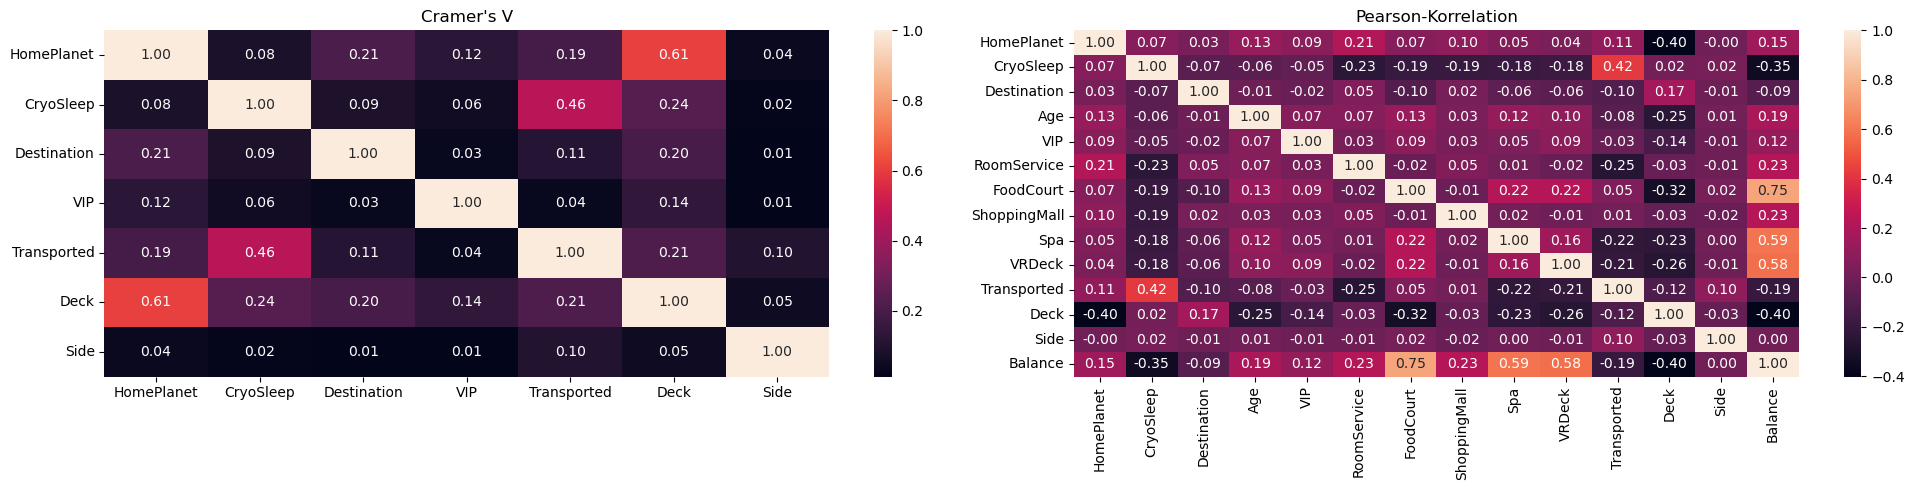

In [71]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
sns.heatmap(corr_matrix.astype(float), annot=True, fmt=".2f")
plt.title("Cramer's V")

plt.subplot(1, 2, 2)
sns.heatmap(df_train_copy.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f")
plt.title("Pearson-Korrelation")

plt.tight_layout()

In [72]:
combined.drop(["PassengerId"], axis=1, inplace=True)

In [73]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    12682 non-null  object 
 1   CryoSleep     12660 non-null  object 
 2   Cabin         12671 non-null  object 
 3   Destination   12696 non-null  object 
 4   Age           12700 non-null  float64
 5   VIP           12674 non-null  object 
 6   RoomService   12707 non-null  float64
 7   FoodCourt     12681 non-null  float64
 8   ShoppingMall  12664 non-null  float64
 9   Spa           12686 non-null  float64
 10  VRDeck        12702 non-null  float64
 11  Name          12676 non-null  object 
 12  Transported   8693 non-null   object 
dtypes: float64(6), object(7)
memory usage: 1.3+ MB


In [140]:
cats = combined.select_dtypes(exclude=[np.number]).columns.tolist()

corr_matrix = pd.DataFrame(index=cats, columns=cats)

for col1 in cats:
    for col2 in cats:
        corr_matrix.loc[col1, col2] = cramers_v(combined[col1], combined[col2])

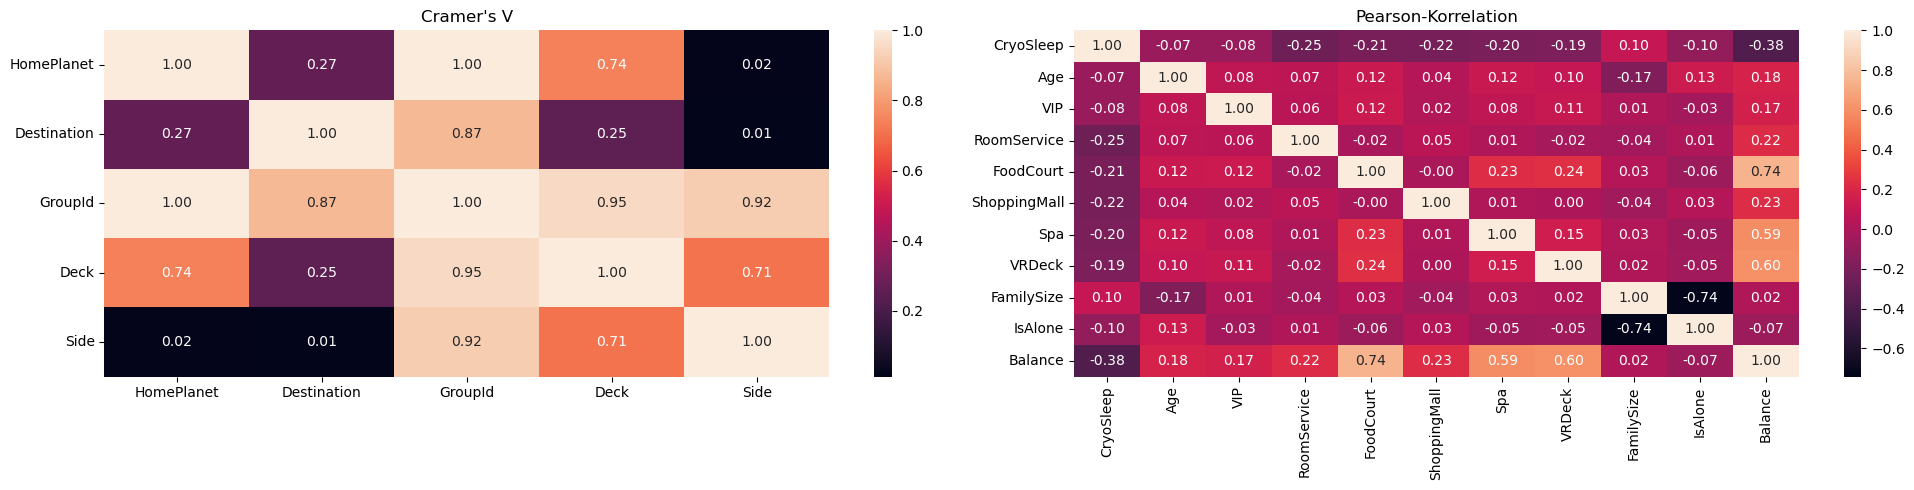

In [141]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
sns.heatmap(corr_matrix.astype(float), annot=True, fmt=".2f")
plt.title("Cramer's V")

plt.subplot(1, 2, 2)
sns.heatmap(combined.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f")
plt.title("Pearson-Korrelation")

plt.tight_layout()

In [144]:
combined["AgeGroup"] = pd.qcut(combined["Age"], 5)
combined.drop("Age", axis=1, inplace=True)

combined["AgeGroup"] = OrdinalEncoder().fit_transform(combined[["AgeGroup"]]).flatten()

In [147]:
combined

,HomePlanet,CryoSleep,Destination,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupId,FamilySize,IsAlone,Deck,Side,Balance,AgeGroup
0,Europa,0,TRAPPIST-1e,0,0.0,0.0,0.0,0.0,0.0,0001,1.0,1,B,P,0.0,3.0
1,Earth,0,TRAPPIST-1e,0,109.0,9.0,25.0,549.0,44.0,0002,1.0,1,F,S,736.0,1.0
2,Europa,0,TRAPPIST-1e,1,43.0,3576.0,0.0,6715.0,49.0,0003,2.0,0,A,S,10383.0,4.0
3,Europa,0,TRAPPIST-1e,0,0.0,1283.0,371.0,3329.0,193.0,0003,2.0,0,A,S,5176.0,3.0
4,Earth,0,TRAPPIST-1e,0,303.0,70.0,151.0,565.0,2.0,0004,1.0,1,F,S,1091.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,Earth,1,TRAPPIST-1e,0,0.0,0.0,0.0,0.0,0.0,9266,2.0,0,G,S,0.0,3.0
12966,Earth,0,TRAPPIST-1e,0,0.0,847.0,17.0,10.0,144.0,9269,1.0,1,M,M,1018.0,4.0
12967,Mars,1,55 Cancri e,0,0.0,0.0,0.0,0.0,0.0,9271,1.0,1,D,P,0.0,2.0
12968,Europa,0,TRAPPIST-1e,0,0.0,2680.0,0.0,0.0,523.0,9273,1.0,1,D,P,3203.0,2.0


In [155]:
combined["Deck"] = combined["Deck"].replace(["B", "C"], "BC")
combined["Deck"] = combined["Deck"].replace(["D", "E", "F"], "DEF")
combined["Deck"] = combined["Deck"].replace(["G", "M"], "GM")

In [ ]:
# A, BC, DEF, GM, T
combined = pd.get_dummies(
    combined,
    columns=["HomePlanet", "Destination", "Side", "Deck"],
    prefix=["HomePlanet", "Destination", "Side", "Deck"],
    dtype=int,
)

combined

,CryoSleep,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupId,FamilySize,IsAlone,Deck,Side,Balance,AgeGroup,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,0,0.0,0.0,0.0,0.0,0.0,0001,1.0,1,B,P,0.0,3.0,0,1,0,0,0,1
1,0,0,109.0,9.0,25.0,549.0,44.0,0002,1.0,1,F,S,736.0,1.0,1,0,0,0,0,1
2,0,1,43.0,3576.0,0.0,6715.0,49.0,0003,2.0,0,A,S,10383.0,4.0,0,1,0,0,0,1
3,0,0,0.0,1283.0,371.0,3329.0,193.0,0003,2.0,0,A,S,5176.0,3.0,0,1,0,0,0,1
4,0,0,303.0,70.0,151.0,565.0,2.0,0004,1.0,1,F,S,1091.0,0.0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,1,0,0.0,0.0,0.0,0.0,0.0,9266,2.0,0,G,S,0.0,3.0,1,0,0,0,0,1
12966,0,0,0.0,847.0,17.0,10.0,144.0,9269,1.0,1,M,M,1018.0,4.0,1,0,0,0,0,1
12967,1,0,0.0,0.0,0.0,0.0,0.0,9271,1.0,1,D,P,0.0,2.0,0,0,1,1,0,0
12968,0,0,0.0,2680.0,0.0,0.0,523.0,9273,1.0,1,D,P,3203.0,2.0,0,1,0,0,0,1


### Simple Feature-Engineering, for Validation


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [150]:
combined = pd.concat([df_train, df_test], sort=False).reset_index(drop=True)

In [151]:
combined.drop(["PassengerId", "Name", "Cabin", "Transported"], axis=1, inplace=True)

In [102]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    12682 non-null  object 
 1   CryoSleep     12660 non-null  object 
 2   Destination   12696 non-null  object 
 3   Age           12700 non-null  float64
 4   VIP           12674 non-null  object 
 5   RoomService   12707 non-null  float64
 6   FoodCourt     12681 non-null  float64
 7   ShoppingMall  12664 non-null  float64
 8   Spa           12686 non-null  float64
 9   VRDeck        12702 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1013.4+ KB


- HomePlanet, Destination = Ordinal
- Age = bins
- CryoSleep, VIP = Float
- Cabin, Name, PassengerID = drop


In [152]:
nummeric_imputation = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(combined.select_dtypes(include=[np.number])),
    columns=combined.select_dtypes(include=[np.number]).columns,
)
nummeric_imputation

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0
4,16.0,303.0,70.0,151.0,565.0,2.0
...,...,...,...,...,...,...
12965,34.0,0.0,0.0,0.0,0.0,0.0
12966,42.0,0.0,847.0,17.0,10.0,144.0
12967,27.0,0.0,0.0,0.0,0.0,0.0
12968,27.0,0.0,2680.0,0.0,0.0,523.0


In [153]:
cat_imputation = pd.DataFrame(
    SimpleImputer(strategy="most_frequent").fit_transform(combined.select_dtypes(exclude=[np.number])),
    columns=combined.select_dtypes(exclude=[np.number]).columns,
)
cat_imputation

,HomePlanet,CryoSleep,Destination,VIP
0,Europa,False,TRAPPIST-1e,False
1,Earth,False,TRAPPIST-1e,False
2,Europa,False,TRAPPIST-1e,True
3,Europa,False,TRAPPIST-1e,False
4,Earth,False,TRAPPIST-1e,False
...,...,...,...,...
12965,Earth,True,TRAPPIST-1e,False
12966,Earth,False,TRAPPIST-1e,False
12967,Mars,True,55 Cancri e,False
12968,Europa,False,TRAPPIST-1e,False


In [154]:
cat = list(combined.select_dtypes(exclude=[np.number]))
num = list(combined.select_dtypes(include=[np.number]))

combined[cat] = cat_imputation
combined[num] = nummeric_imputation
combined.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0


In [155]:
combined["AgeGroup"] = pd.qcut(combined["Age"], 5)
combined.drop("Age", axis=1, inplace=True)

combined["AgeGroup"] = OrdinalEncoder().fit_transform(combined[["AgeGroup"]]).flatten()

In [156]:
combined["VIP"] = combined["VIP"].astype(int)
combined["CryoSleep"] = combined["CryoSleep"].astype(int)

combined = pd.get_dummies(combined, columns=["HomePlanet", "Destination"], prefix=["HomePlanet", "Destination"]).astype(
    int
)

combined

,CryoSleep,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,AgeGroup,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,0,0,0,0,0,0,3,0,1,0,0,0,1
1,0,0,109,9,25,549,44,1,1,0,0,0,0,1
2,0,1,43,3576,0,6715,49,4,0,1,0,0,0,1
3,0,0,0,1283,371,3329,193,3,0,1,0,0,0,1
4,0,0,303,70,151,565,2,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,1,0,0,0,0,0,0,3,1,0,0,0,0,1
12966,0,0,0,847,17,10,144,4,1,0,0,0,0,1
12967,1,0,0,0,0,0,0,2,0,0,1,1,0,0
12968,0,0,0,2680,0,0,523,2,0,1,0,0,0,1


In [157]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   CryoSleep                  12970 non-null  int32
 1   VIP                        12970 non-null  int32
 2   RoomService                12970 non-null  int32
 3   FoodCourt                  12970 non-null  int32
 4   ShoppingMall               12970 non-null  int32
 5   Spa                        12970 non-null  int32
 6   VRDeck                     12970 non-null  int32
 7   AgeGroup                   12970 non-null  int32
 8   HomePlanet_Earth           12970 non-null  int32
 9   HomePlanet_Europa          12970 non-null  int32
 10  HomePlanet_Mars            12970 non-null  int32
 11  Destination_55 Cancri e    12970 non-null  int32
 12  Destination_PSO J318.5-22  12970 non-null  int32
 13  Destination_TRAPPIST-1e    12970 non-null  int32
dtypes: int32(14)
memory us

### Model, Training and Prediction


In [160]:
X_train = combined[: len(df_train)]
X_train["Transported"] = df_train.loc[X_train.index, "Transported"]

C:\Users\alexe\AppData\Local\Temp\ipykernel_20876\3690927734.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["Transported"] = df_train.loc[X_train.index, "Transported"]


In [161]:
X_train["Transported"] = X_train["Transported"].astype(int)

C:\Users\alexe\AppData\Local\Temp\ipykernel_20876\1187065688.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["Transported"] = X_train["Transported"].astype(int)


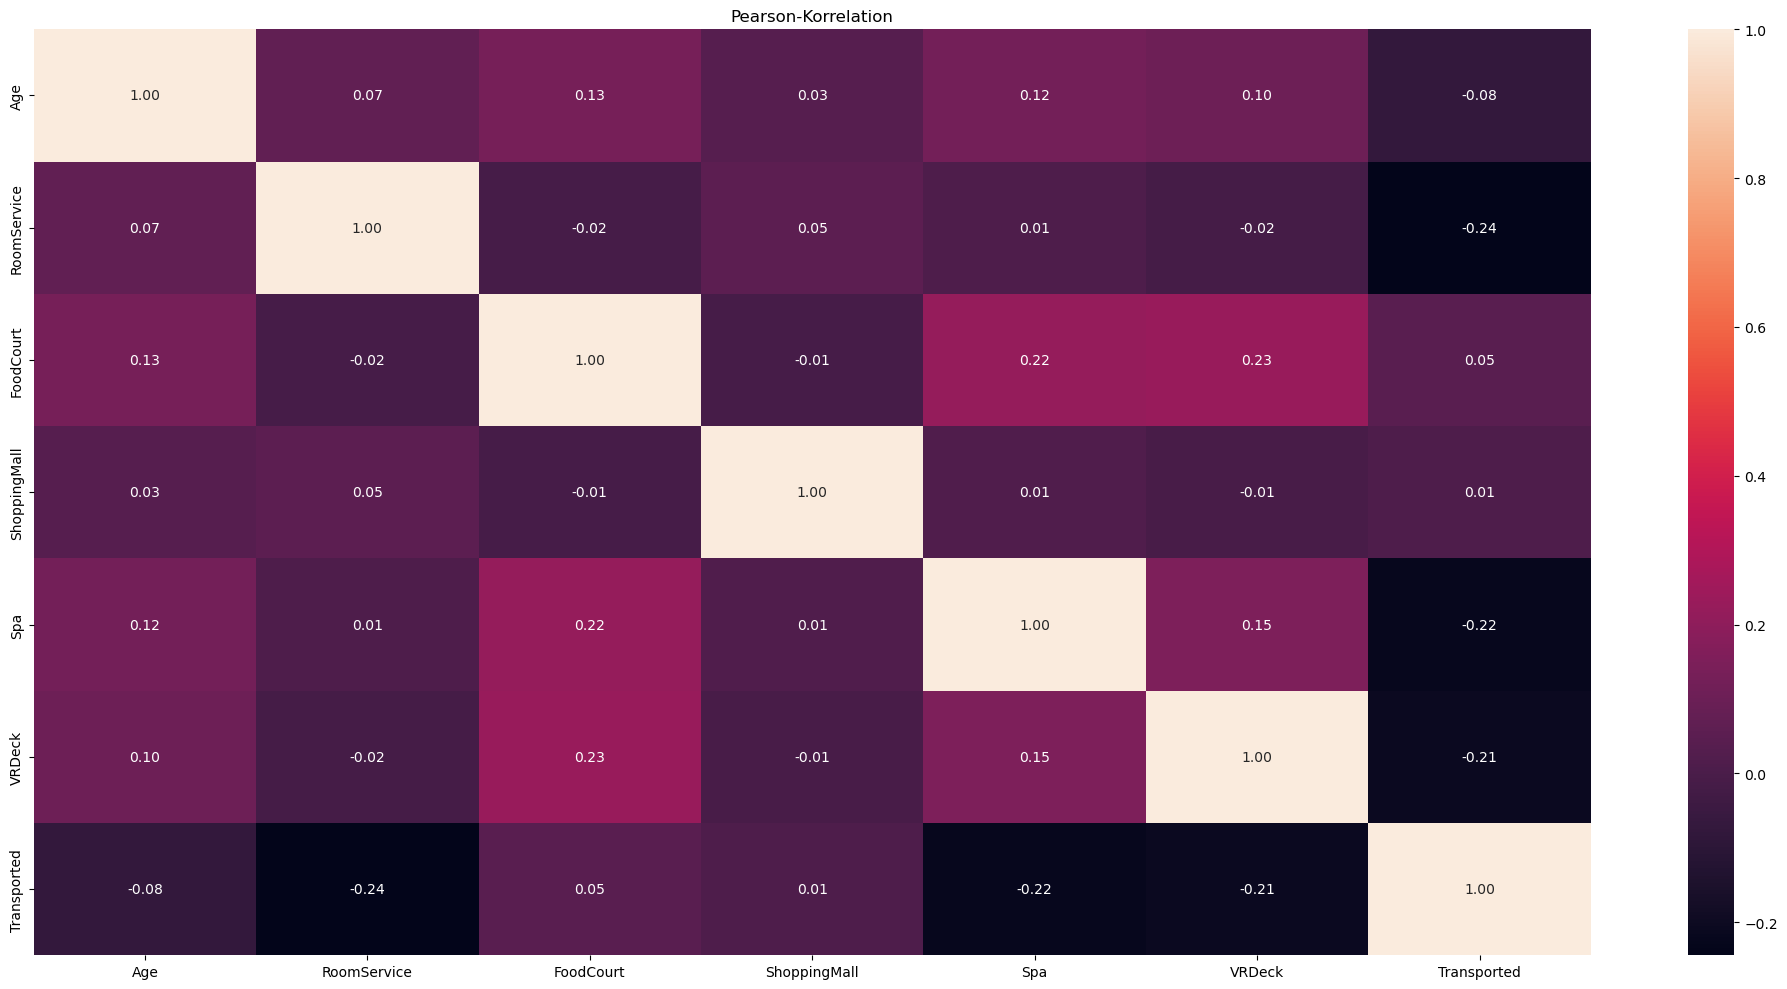

In [118]:
plt.figure(figsize=(20, 10))
sns.heatmap(X_train.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f")
plt.title("Pearson-Korrelation")

plt.tight_layout()

Zu pruefunde Modelle:

- SVC, LinearSVC, Perceptron, SGDClassifier, LogisticRegression
- RandomForestClassifier, XGBClassifier
- KNeighborsClassifier
- GaussianNB
- DecisionTreeClassifier


In [20]:
with open("../data/spaceship-titanic/combined_spaceship.pickle", "rb") as file:
    loaded_data = pickle.load(file)
    loaded_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CryoSleep                  12970 non-null  int32  
 1   VIP                        12970 non-null  int32  
 2   RoomService                12970 non-null  float64
 3   FoodCourt                  12970 non-null  float64
 4   ShoppingMall               12970 non-null  float64
 5   Spa                        12970 non-null  float64
 6   VRDeck                     12970 non-null  float64
 7   Balance                    12970 non-null  float64
 8   GroupId                    12970 non-null  int32  
 9   FamilySize                 12970 non-null  int64  
 10  IsAlone                    12970 non-null  int32  
 11  AgeGroup                   12970 non-null  float64
 12  HomePlanet_Earth           12970 non-null  int32  
 13  HomePlanet_Europa          12970 non-null  int

In [21]:
from sklearn.model_selection import train_test_split

# X_train, X_val, y_train, y_val = train_test_split(loaded_data[: len(df_train)], df_train["Transported"], test_size=0.2, random_state=42)


X_train = loaded_data[: len(df_train)]
y_train = df_train["Transported"]
X_test = loaded_data[len(df_train) :]
X_train.shape, y_train.shape, X_test.shape

((8693, 30), (8693,), (4277, 30))

In [22]:
X_test

,CryoSleep,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Balance,GroupId,FamilySize,...,Side_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_M,Deck_T
8693,1,0,0.0,0.0,0.0,0.0,0.0,0.0,13,1,...,1,0,0,0,0,0,0,1,0,0
8694,0,0,0.0,9.0,0.0,2823.0,0.0,2832.0,18,1,...,1,0,0,0,0,0,1,0,0,0
8695,1,0,0.0,0.0,0.0,0.0,0.0,0.0,19,1,...,1,0,0,1,0,0,0,0,0,0
8696,0,0,0.0,6652.0,0.0,181.0,585.0,7418.0,21,1,...,1,0,0,1,0,0,0,0,0,0
8697,0,0,10.0,0.0,635.0,0.0,0.0,645.0,23,1,...,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,1,0,0.0,0.0,0.0,0.0,0.0,0.0,9266,2,...,1,0,0,0,0,0,0,1,0,0
12966,0,0,0.0,847.0,17.0,10.0,144.0,1018.0,9269,1,...,0,0,0,0,0,0,0,0,1,0
12967,1,0,0.0,0.0,0.0,0.0,0.0,0.0,9271,1,...,0,0,0,0,1,0,0,0,0,0
12968,0,0,0.0,2680.0,0.0,0.0,523.0,3203.0,9273,1,...,0,0,0,0,1,0,0,0,0,0


In [138]:
full_pipeline = get_pipeline(XGBClassifier(random_state=SEED))

In [139]:
print(type(full_pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [158]:
# Pipeline ohne letzten Schritt (clf) bauen
pre_only = Pipeline(full_pipeline.steps[:-1])

X_trans = pre_only.fit_transform(df_train, y_train)
print(type(X_trans), X_trans.shape)

<class 'pandas.core.frame.DataFrame'> (8693, 32)


In [163]:
def custom_val_score(clf, score_func=balanced_accuracy_score):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        clf.fit(X_t, y_t)
        scores.append(score_func(y_v, clf.predict(X_v)))

    return round(np.array(scores).mean() * 100, 3)

In [23]:
def simple_predict(model):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Modell: {}".format(str(model.__class__).split(".")[-1]))
    print(f"Accuracy: {round(model.score(X_train, y_train) * 100, 2)}")

    scores = cross_val_score(model, X_train, y_train, cv=5)
    print("Mean = {}, Scores : {}".format(round(np.mean(scores) * 100, 2), scores))
    return y_pred

In [116]:
y_pred_logreg = simple_predict(LogisticRegression(random_state=SEED))
y_pred_svc = simple_predict(SVC(random_state=SEED))
y_pred_lsvc = simple_predict(LinearSVC(random_state=SEED))
y_pred_sgd = simple_predict(SGDClassifier(random_state=SEED))
y_pred_knn = simple_predict(KNeighborsClassifier())
y_pred_gaus = simple_predict(GaussianNB())
y_pred_perceptron = simple_predict(Perceptron(random_state=SEED))
y_pred_dtree = simple_predict(DecisionTreeClassifier(random_state=SEED))
y_pred_randomforest = simple_predict(RandomForestClassifier(random_state=SEED))
y_pred_xgb = simple_predict(XGBClassifier(random_state=SEED))

Modell: LogisticRegression'>
Accuracy: 78.44
Mean = 77.34, Scores : [0.75848189 0.77170788 0.7947096  0.77963176 0.76237054]
Modell: SVC'>
Accuracy: 78.65
Mean = 78.21, Scores : [0.7653824  0.77285796 0.7826337  0.79804373 0.79171461]
Modell: LinearSVC'>
Accuracy: 78.95
Mean = 78.37, Scores : [0.77055779 0.78493387 0.79930995 0.78423475 0.77963176]
Modell: SGDClassifier'>
Accuracy: 75.62
Mean = 64.21, Scores : [0.76250719 0.53018976 0.52731455 0.79804373 0.59263521]
Modell: KNeighborsClassifier'>
Accuracy: 82.93
Mean = 58.16, Scores : [0.54629097 0.54686601 0.56814261 0.71173763 0.53509781]
Modell: GaussianNB'>
Accuracy: 73.6
Mean = 73.5, Scores : [0.72915469 0.71132835 0.75043128 0.76812428 0.71576525]
Modell: Perceptron'>
Accuracy: 75.65
Mean = 72.81, Scores : [0.75963197 0.74295572 0.54744106 0.79574223 0.79459148]
Modell: DecisionTreeClassifier'>
Accuracy: 99.45
Mean = 67.49, Scores : [0.53651524 0.70442783 0.73720529 0.72151899 0.67491369]
Modell: RandomForestClassifier'>
Accuracy

In [ ]:
import optuna


# Optuna for XGB failed, since XGB performs its own Overfitting optimization, so Optuna only hinders it.
def objective(trial):
    xgb_params = dict(
        max_depth=trial.suggest_int("max_depth", 2, 10),
        learning_rate=trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
        n_estimators=trial.suggest_int("n_estimators", 200, 5000),
        min_child_weight=trial.suggest_int("min_child_weight", 2, 10),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.2, 1.0),
        subsample=trial.suggest_float("subsample", 0.2, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1e2, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1e2, log=True),
    )
    xgb = XGBClassifier(**xgb_params)
    xgb.fit(X_train, y_train)
    xgb.score(X_val, y_val)
    acc_xgb = round(xgb.score(X_val, y_val) * 100, 2)
    return acc_xgb


study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=20)
xgb_params = study.best_params

In [140]:
xgb_params

{'max_depth': 8,
 'learning_rate': 0.015059419264668417,
 'n_estimators': 2182,
 'min_child_weight': 5,
 'colsample_bytree': 0.9074559347502931,
 'subsample': 0.8917815110329494,
 'reg_alpha': 0.007376158649524467,
 'reg_lambda': 25.55868344562692}

In [106]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings(action="ignore", category=ConvergenceWarning)

In [24]:
df_train

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [165]:
df_test

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


In [109]:
df_train.drop(["Transported"], axis=1, inplace=True)

In [163]:
model = get_pipeline(XGBClassifier(random_state=SEED, enable_categorical=True))

model.fit(df_train, y_train)
y_pred = model.predict(df_test)

print("Modell: {}".format(str(model.__class__).split(".")[-1]))
print(f"Accuracy: {round(model.score(df_train, y_train) * 100, 2)}")

# scores = cross_val_score(model, df_train, y_train, cv=5)
# print("Mean = {}, Scores : {}".format(round(np.mean(scores) * 100, 2), scores))

Modell: Pipeline'>
Accuracy: 92.12


c:\Users\alexe\miniconda3\envs\homl3\lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\alexe\miniconda3\envs\homl3\lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:
xgb = get_pipeline(XGBClassifier(random_state=SEED))
# rdf = RandomForestClassifier(random_state=SEED)
lr = get_pipeline(LogisticRegression(random_state=SEED))
# knn = KNeighborsClassifier(n_neighbors=5)
lgbm = get_pipeline(LGBMClassifier(random_state=SEED))

svc = get_pipeline(SVC(kernel="rbf", probability=True, random_state=SEED))


# VotingClassifier
voting_clf = VotingClassifier(
    estimators=[("xgb", xgb), ("lr", lr), ("svc", svc), ("lgbm", lgbm)],
    voting="soft",  # 'soft' für Wahrscheinlichkeiten, 'hard' für Mehrheitsentscheid
    weights=[2, 1, 1, 2],
)


voting_clf.fit(df_train, y_train)
y_pred_voting = voting_clf.predict(df_test)


print(f"Accuracy: {round(voting_clf.score(df_train, y_train) * 100, 2)}")
scores = cross_val_score(voting_clf, df_train, y_train, cv=5)

print("Mean = {}, Scores : {}".format(round(np.mean(scores) * 100, 2), scores))

# XGB + LR + SVC (kernel="rbf", probability=True) = 84.21 acc , 80.50% submission -> soft
# XGB + RBF + LR + SVC (kernel="rbf", probability=True) = 90.64 acc ,cv = 77.10, 80.336% submission -> soft
# XGB + RBF + LR + SVC (kernel="rbf", probability=True) = 90.59 acc ,cv = 76.82, 80.126% submission -> hard

# XGB + LR + LGBM + SVC (kernel="rbf", probability=True) = 85.31 acc ,cv = 73.84, 80.57% submission -> soft
# XGB + LGBM + SVC (kernel="rbf", probability=True) = 87.2 acc ,cv = 70.30, 80.50% submission -> soft

# XGB + LR + LGBM + SVC (kernel="rbf", probability=True) = 87.91 acc ,cv = 70.71, 80.64% submission -> soft, weights [2, 1, 2, 1]
# Rank: 436

In [114]:
from sklearn.ensemble import StackingClassifier

xgb = XGBClassifier(random_state=SEED)
# rdf = RandomForestClassifier(random_state=SEED)
# lr = LogisticRegression(random_state=SEED)
# knn = KNeighborsClassifier(n_neighbors=5)
lgbm = LGBMClassifier(random_state=SEED)
svc = SVC(kernel="rbf", probability=True, random_state=SEED)

stacking_clf = StackingClassifier(
    estimators=[
        ("xgb", xgb),
        (
            "lgbm",
            lgbm,
        ),
        ("svc", svc),
    ],
    final_estimator=LogisticRegression(),  # Meta-learner
    cv=5,
)

stacking_clf.fit(X_train, y_train)
y_pred_stacking = stacking_clf.predict(X_test)

print(f"Accuracy: {round(stacking_clf.score(X_train, y_train) * 100, 2)}")
scores = cross_val_score(stacking_clf, X_train, y_train, cv=5)

print("Mean = {}, Scores : {}".format(round(np.mean(scores) * 100, 2), scores))

# XGB + LGBM + SVC (kernel="rbf", probability=True), LR= 80.82 acc ,cv = 77.37, 79.822% submission

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4378, number of negative: 4315
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1839
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,503624 -> initscore=0,014495
[LightGBM] [Info] Start training from score 0,014495
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3502, number of negative: 3452
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000873 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1839
[LightGBM] [Info] Numb

KeyboardInterrupt: 

In [120]:
model_xgb_optuna = XGBClassifier(random_state=SEED, **xgb_params)
model_xgb_optuna.fit(X_train_full, y_train_full)
y_pred_xgb_optuna = model_xgb_optuna.predict(X_test)

acc_xgb_optuna = round(model_xgb_optuna.score(X_train_full, y_train_full) * 100, 2)
acc_xgb_optuna

87.94

In [54]:
model_xgb_optuna.get_xgb_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8802951343552081,
 'eval_metric': None,
 'gamma': None,
 'gpu_id': None,
 'grow_policy': None,
 'interaction_constraints': None,
 'learning_rate': 0.09850675163012623,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': 4,
 'monotone_constraints': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'predictor': None,
 'random_state': 42,
 'reg_alpha': 0.0008753617168021921,
 'reg_lambda': 0.01711033969777324,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.9969924317389438,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [259]:
model_xgb = XGBClassifier(random_state=SEED)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

acc_xgb = round(model_xgb.score(X_train, y_train) * 100, 2)
acc_xgb

# 86 Default -> Simple Imputer median + most frequent, OneHotEncoder, XGBClassifier

# 91.38 all -> submission = 80.009%
# 87.21 without Balance cols -> submission = 74.35%
# 88,48 without Sides -> submission = 79.14%

# 91.90 all, but better fill order -> submission = 80.032% # 1240th place
# 91.79 with FamilySizeGrouped w/o FamilySize-> submission = 79.68%
# 90.88 binned Balance w/o Balance -> submission = 79.78%
# 92.43 unbinned Deck -> submission = 80.406% # 765th place

92.44

Text(0.5, 0, 'XGB Feature Importance')

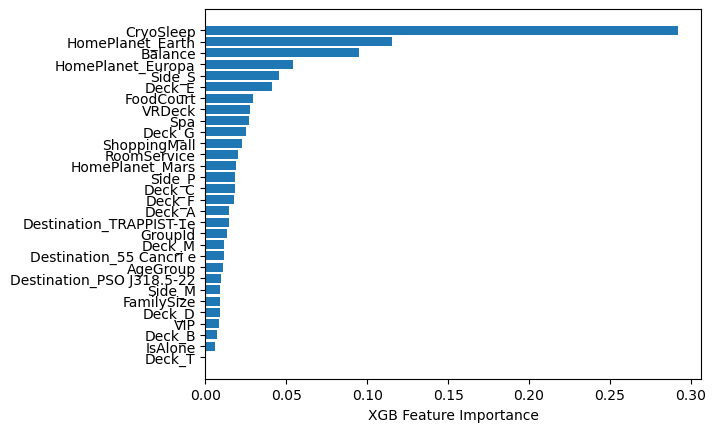

In [ ]:
idx = model_xgb.feature_importances_.argsort()
plt.barh(X_train.columns[idx], model_xgb.feature_importances_[idx])
plt.xlabel("XGB Feature Importance")

In [197]:
models = pd.DataFrame(
    {
        "Model": [
            "LinearSVC",
            "SVC",
            "LogisticRegression",
            "SGDClassifier",
            "KNeighborsClassifier",
            "GaussianNB",
            "Perceptron",
            "DecisionTreeClassifier",
            "RandomForestClassifier",
            "XGBClassifier",
        ],
        "Acc": [
            acc_lsvc,
            acc_svc,
            acc_log,
            acc_sgd,
            acc_knn,
            acc_gaus,
            acc_perceptron,
            acc_dtree,
            acc_randomforest,
            acc_xgb,
        ],
    }
)
models.sort_values(by="Acc", ascending=False)

,Model,Acc
7,DecisionTreeClassifier,91.36
8,RandomForestClassifier,91.36
9,XGBClassifier,86.07
4,KNeighborsClassifier,80.71
1,SVC,78.98
0,LinearSVC,78.45
2,LogisticRegression,78.25
3,SGDClassifier,74.69
5,GaussianNB,71.44
6,Perceptron,71.03


In [258]:
submission = pd.DataFrame({"PassengerId": df_test["PassengerId"], "Transported": pred.astype(bool)})
submission.to_csv("./data/output-submissions/spaceTitanic/SampleAPipeSubmission.csv", index=False)

In [ ]:
model_dtree_optimized = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=SEED,
)
model_dtree_optimized.fit(X_train, y_train)
y_pred_dtree_optimized = model_dtree_optimized.predict(X_test)
acc_dtree_optimized = round(model_dtree_optimized.score(X_train, y_train) * 100, 2)
acc_dtree_optimized

79.1